In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [25]:
df = pd.read_csv("Iris.csv")

In [26]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [27]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [28]:
df_with_labels = df.copy()
df_with_labels['Cluster'] = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

In [29]:
df_with_labels.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


In [30]:
df_with_labels.drop(["Species"], axis=1, inplace=True)

In [31]:
df_with_labels.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Cluster
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [32]:
df_with_labels.drop(["Id"], axis=1, inplace=True)

In [33]:
df_with_labels.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Cluster
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [34]:
df_with_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Cluster        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


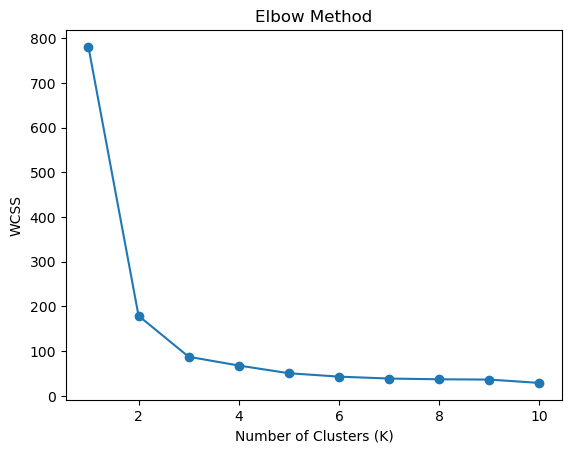

In [35]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Try different K values
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_with_labels)   # use df or df[['col1','col2']] if needed
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot the graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

K = 2, Silhouette Score = 0.590106337998464
K = 3, Silhouette Score = 0.47166802378053424
K = 4, Silhouette Score = 0.40356012351518594
K = 5, Silhouette Score = 0.3712515563531535
K = 6, Silhouette Score = 0.37811864996326716
K = 7, Silhouette Score = 0.3611812339983737
K = 8, Silhouette Score = 0.3646903731328848
K = 9, Silhouette Score = 0.36689062221772384
K = 10, Silhouette Score = 0.37465634485296184


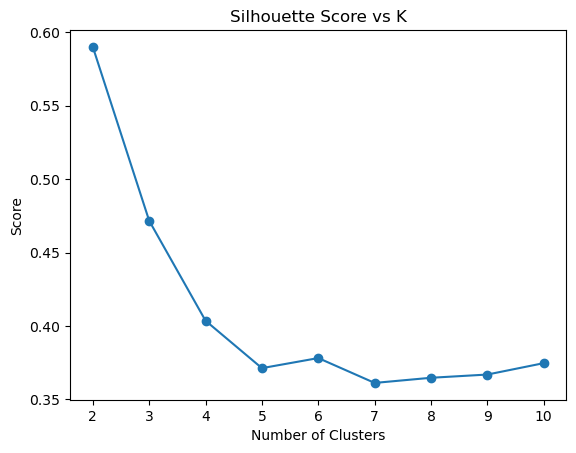

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Scale data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_with_labels)

# Step 2: Try different K values
for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    
    score = silhouette_score(df_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score}")
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    scores.append(silhouette_score(df_scaled, labels))

import matplotlib.pyplot as plt
plt.plot(range(2, 11), scores, marker='o')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.show()

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Scale data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_with_labels)

# Step 2: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)

# Step 3: Get results
labels = kmeans.labels_        # cluster assigned to each point
centroids = kmeans.cluster_centers_

# Add cluster column to df
df['Cluster'] = labels

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        2  
1        1  
2        1  
3        1  
4        2  


In [38]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,2
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,2


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
 6   Cluster        150 non-null    int32  
dtypes: float64(4), int32(1), int64(1), object(1)
memory usage: 7.7+ KB


In [40]:
df['Cluster'].value_counts()

Cluster
0    96
2    32
1    22
Name: count, dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
 6   Cluster        150 non-null    int32  
dtypes: float64(4), int32(1), int64(1), object(1)
memory usage: 7.7+ KB


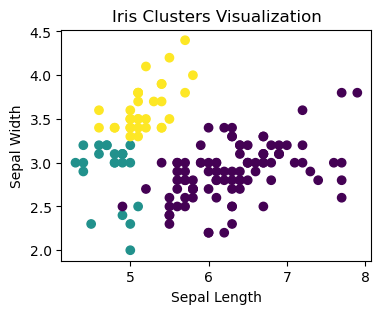

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))

plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'], c=df['Cluster'])

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Clusters Visualization")

plt.show()